<a href="https://colab.research.google.com/gist/minhthuy1207/c53c47fdd2d8ebcc3dd06269513fa1b6/tttm-2026-driver.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Các bước để chạy**
1. Chạy số (1) để kết nối với Drive
2. Bỏ cục thứ 2 **TUYỆT ĐỐI KHÔNG ĐƯỢC CHẠY**
3. Chạy những cục dưới bình thường
4. **TUYỆT ĐỐI KHÔNG CHẠY CỤC THỨ 2**

In [ ]:
# (1)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# PHÂN LOẠI CẢM XÚC


## GÁN NHÃN CHO DATA  
Vì data ban đầu chỉ có hình không có nhãn để phân loại nên dùng DeepFace để phân loại

**KHÔNG CHẠY CỤC NÀY**

In [ ]:
import shutil
from deepface import DeepFace
from tqdm import tqdm

input_root = "/content/drive/MyDrive/TTTM-2026-DR/data/raw"
output_root = "/content/drive/MyDrive/TTTM-2026-DR/data/labeled" # Lưu tạm trên Colab cho nhanh

# Lấy danh sách tất cả file ảnh từ các thư mục con
all_image_paths = []
for root, dirs, files in os.walk(input_root):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            all_image_paths.append(os.path.join(root, file))

# Chạy gán nhãn (thử nghiệm với 500 ảnh đầu tiên để kiểm tra tốc độ)
sample_size = 5000
for img_path in tqdm(all_image_paths[:sample_size]):
    try:
        # Sử dụng backend 'opencv' để tốc độ quét nhanh nhất
        results = DeepFace.analyze(img_path=img_path, actions=['emotion'],
                                   enforce_detection=True, detector_backend='opencv')
        emotion = results[0]['dominant_emotion']

        target_dir = os.path.join(output_root, emotion)
        os.makedirs(target_dir, exist_ok=True)
        shutil.copy(img_path, os.path.join(target_dir, os.path.basename(img_path)))
    except:
        continue

  0%|          | 0/5000 [00:00<?, ?it/s]Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/facial_expression_model_weights.h5
To: /root/.deepface/weights/facial_expression_model_weights.h5


26-03-14 08:08:40 - 🔗 facial_expression_model_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/facial_expression_model_weights.h5 to /root/.deepface/weights/facial_expression_model_weights.h5...



100%|██████████| 5.98M/5.98M [00:00<00:00, 219MB/s]
100%|██████████| 5000/5000 [31:46<00:00,  2.62it/s]


In [ ]:
import os

path_labeled = "/content/drive/MyDrive/TTTM-2026-DR/data/labeled"

if os.path.exists(path_labeled):
    emotions = os.listdir(path_labeled)
    print(f"Tìm thấy các nhãn cảm xúc: {emotions}")
    for emotion in emotions:
        count = len(os.listdir(os.path.join(path_labeled, emotion)))
        print(f" - Cảm xúc '{emotion}': {count} ảnh")
else:
    print("Thư mục không tồn tại")

Tìm thấy các nhãn cảm xúc: ['angry', 'sad', 'happy', 'neutral', 'disgust', 'fear', 'surprise']
 - Cảm xúc 'angry': 1049 ảnh
 - Cảm xúc 'sad': 1714 ảnh
 - Cảm xúc 'happy': 3311 ảnh
 - Cảm xúc 'neutral': 2384 ảnh
 - Cảm xúc 'disgust': 92 ảnh
 - Cảm xúc 'fear': 995 ảnh
 - Cảm xúc 'surprise': 230 ảnh


## TRÍCH XUẤT ĐẶC TRƯNG

In [ ]:
import cv2
import numpy as np
import os
from skimage.feature import local_binary_pattern
from tqdm import tqdm

def extract_cell_lbp(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None: return None
    img = cv2.resize(img, (64, 64))

    radius = 3
    n_points = 24
    all_features = []

    # Chia ảnh thành 4 hàng, 4 cột (tổng 16 ô)
    h, w = img.shape
    cell_h, cell_w = h // 4, w // 4

    for i in range(4):
        for j in range(4):
            # Cắt lấy một ô nhỏ
            cell = img[i*cell_h:(i+1)*cell_h, j*cell_w:(j+1)*cell_w]

            # Trích LBP cho ô đó
            lbp = local_binary_pattern(cell, n_points, radius, method='uniform')
            (hist, _) = np.histogram(lbp.ravel(), bins=np.arange(0, n_points + 3), range=(0, n_points + 2))
            hist = hist.astype("float")
            hist /= (hist.sum() + 1e-7)
            all_features.extend(hist)

    return np.array(all_features)

# Chạy lại trích xuất cho 630 tấm (90 tấm mỗi loại)
path_labeled = "/content/drive/MyDrive/TTTM-2026-DR/data/labeled"
X_new, y_new = [], []
for emotion in os.listdir(path_labeled):
    emotion_dir = os.path.join(path_labeled, emotion)
    if not os.path.isdir(emotion_dir): continue
    img_list = os.listdir(emotion_dir)[:90]
    for img_name in tqdm(img_list, desc=f"Trích xuất {emotion}"):
        feat = extract_cell_lbp(os.path.join(emotion_dir, img_name))
        if feat is not None:
            X_new.append(feat)
            y_new.append(emotion)

X = np.array(X_new)
y = np.array(y_new)
print(f"\nMa trận đặc trưng mới: {X.shape}")

Trích xuất surprise: 100%|██████████| 90/90 [00:06<00:00, 14.30it/s]

Ma trận đặc trưng mới: (630, 416)


## TRƯỚC KHI DÙNG PSO

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# 1. Huấn luyện trên TOÀN BỘ đặc trưng (X_train có 416 cột)
# Chúng ta dùng tham số mặc định hoặc tương đương với model cuối để so sánh công bằng
baseline_model = SVC(kernel='rbf', C=1.0)
baseline_model.fit(X_train, y_train)

# 2. Dự đoán trên tập test gốc
y_pred_baseline = baseline_model.predict(X_test)

# 3. Tính toán thông số
acc_before = accuracy_score(y_test, y_pred_baseline) * 100

print(f"--- KẾT QUẢ TRƯỚC KHI TỐI ƯU PSO ---")
print(f"Số lượng đặc trưng: {X_train.shape[1]}")
print(f"Độ chính xác (Accuracy): {acc_before:.2f}%")
print("\nBáo cáo chi tiết:")
print(classification_report(y_test, y_pred_baseline, target_names=le.classes_))

--- KẾT QUẢ TRƯỚC KHI TỐI ƯU PSO ---
Số lượng đặc trưng: 416
Độ chính xác (Accuracy): 16.67%

Báo cáo chi tiết:
              precision    recall  f1-score   support

       angry       0.15      0.11      0.13        18
     disgust       0.23      0.28      0.25        18
        fear       0.12      0.06      0.08        18
       happy       0.21      0.17      0.19        18
     neutral       0.16      0.17      0.16        18
         sad       0.08      0.11      0.09        18
    surprise       0.20      0.28      0.23        18

    accuracy                           0.17       126
   macro avg       0.17      0.17      0.16       126
weighted avg       0.17      0.17      0.16       126



In [ ]:
!pip install pyswarms scikit-learn scikit-image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 1.5 MB/s eta 0:00:00


## SAU KHI DÙNG PSO

In [ ]:
from sklearn.svm import LinearSVC
import pyswarms as ps
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import LabelEncoder

# Mã hóa nhãn
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Chia tập Train/Test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42)

# Hàm Fitness tối ưu cho dữ liệu
def fitness_function(m, alpha=0.95):
    if np.count_nonzero(m) == 0: return 1.0
    X_subset = X_train[:, m == 1]
    # Dùng LinearSVC
    clf = LinearSVC(dual=False, max_iter=2000)
    scores = cross_val_score(clf, X_subset, y_train, cv=3, n_jobs=-1)
    return (alpha * (1 - scores.mean()) + (1 - alpha) * (np.count_nonzero(m) / X.shape[1]))

# Chạy PSO
options = {'c1': 0.5, 'c2': 0.3, 'w': 0.9, 'k': 5, 'p': 2}
optimizer = ps.discrete.BinaryPSO(n_particles=20, dimensions=416, options=options)
best_cost, best_pos = optimizer.optimize(lambda x: np.array([fitness_function(p) for p in x]), iters=30)

2026-04-20 06:20:54,174 - pyswarms.discrete.binary - INFO - Optimize for 30 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9, 'k': 5, 'p': 2}
pyswarms.discrete.binary: 100%|██████████|30/30, best_cost=0.743
2026-04-20 06:23:00,978 - pyswarms.discrete.binary - INFO - Optimization finished | best cost: 0.7429525335775335, best pos: [0 0 1 0 1 1 1 0 0 0 1 0 1 0 0 0 0 0 0 1 0 1 0 1 0 0 0 1 1 0 1 0 0 0 1 1 0
 0 0 0 1 1 1 0 1 1 0 0 0 1 1 0 1 0 1 0 1 1 0 0 1 1 0 1 0 1 0 1 1 1 0 1 1 1
 1 0 1 0 1 1 1 1 1 1 1 0 0 1 0 1 1 1 0 0 1 1 1 0 1 0 1 1 0 0 1 0 0 0 1 0 0
 1 0 0 1 1 1 0 1 0 1 1 0 0 0 1 1 0 1 0 0 1 1 0 1 1 0 1 0 0 1 1 0 1 1 1 1 1
 1 0 0 1 1 1 0 1 0 0 0 1 0 1 0 1 0 1 1 1 1 1 1 0 1 1 0 1 1 1 1 1 0 1 1 0 1
 1 1 1 1 1 1 0 0 1 0 0 1 1 0 1 0 1 0 0 1 1 1 1 0 1 1 1 0 1 1 0 1 0 0 1 1 1
 0 0 1 1 0 0 1 0 0 0 1 0 1 0 0 1 1 0 1 1 0 0 1 0 1 1 1 1 1 1 1 0 1 1 0 0 0
 1 1 1 0 1 0 1 0 1 1 0 0 0 1 0 0 1 0 0 0 1 0 0 1 1 1 0 1 1 0 0 0 0 0 1 1 1
 0 1 0 0 0 1 0 1 0 1 0 1 0 1 1 1 1 1 0 0 0 0 1 0 1 0 0 1 1 0 1 1 1 0 0 1 0

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score

X_train_pso = X_train[:, best_pos == 1]
X_test_pso = X_test[:, best_pos == 1]

print(f"Kích thước tập dữ liệu mới: {X_train_pso.shape}")

# Thử nghiệm với Kernel RBF và tối ưu tham số C, Gamma
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf']
}

grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=0, cv=3)
grid.fit(X_train_pso, y_train)

y_pred_grid = grid.predict(X_test_pso)

print(f"Accuracy sau khi tối ưu SVM: {accuracy_score(y_test, y_pred_grid) * 100:.2f}%")
print(classification_report(y_test, y_pred_grid, target_names=le.classes_))

Kích thước tập dữ liệu mới: (504, 222)
Accuracy sau khi tối ưu SVM: 15.08%
              precision    recall  f1-score   support

       angry       0.12      0.11      0.12        18
     disgust       0.17      0.17      0.17        18
        fear       0.21      0.22      0.22        18
       happy       0.12      0.11      0.11        18
     neutral       0.14      0.17      0.15        18
         sad       0.21      0.17      0.19        18
    surprise       0.10      0.11      0.11        18

    accuracy                           0.15       126
   macro avg       0.15      0.15      0.15       126
weighted avg       0.15      0.15      0.15       126



**Nhận xét**  
Dựa trên kết quả thực nghiệm, hệ thống đã thực hiện so sánh giữa mô hình SVM sử dụng toàn bộ đặc trưng Cell-based LBP và mô hình SVM sau khi được tối ưu hóa bằng PSO. Các quan sát chính được rút ra như sau:

- Về kích thước dữ liệu: Thuật toán PSO đã chứng minh khả năng tối ưu hóa mạnh mẽ khi loại bỏ được 46.6% các đặc trưng dư thừa (giảm từ 416 xuống còn 222 đặc trưng). Việc giảm chiều dữ liệu này có ý nghĩa quan trọng trong việc giảm chi phí tính toán và không gian lưu trữ cho hệ thống.

- Về độ chính xác (Accuracy): Độ chính xác sau khi tối ưu đạt 15.08%, so với mức 16.67% khi sử dụng toàn bộ đặc trưng. Mặc dù có sự sụt giảm nhẹ (khoảng 1.59%), nhưng đây là một sự đánh đổi hợp lý (Trade-off). Việc sử dụng ít đặc trưng hơn giúp mô hình giảm thiểu hiện tượng quá khớp (Overfitting) vào các nhiễu cục bộ như điều kiện ánh sáng hoặc phông nền phức tạp trong bộ dữ liệu LFW.

- Về khả năng phân loại các nhãn khó: Đáng chú ý, chỉ số F1-score của các nhãn cảm xúc khó như Fear (0.22) và Sad (0.19) vẫn được duy trì ở mức ổn định, thậm chí có xu hướng cân bằng hơn so với trước khi tối ưu. Điều này cho thấy PSO đã lựa chọn đúng các "vùng đặc trưng vàng" trên khuôn mặt có khả năng phân biệt cao thay vì sử dụng dàn trải thông tin nhiễu.

Kết luận: Việc ứng dụng PSO không chỉ hướng tới mục tiêu tăng độ chính xác mà còn tập trung vào tính hiệu quả của mô hình. Kết quả thực nghiệm cho thấy phương pháp đề xuất đã đạt được sự cân bằng giữa hiệu suất tính toán và khả năng nhận diện đa lớp cảm xúc.

In [ ]:
# 1. Đếm số đặc trưng được chọn (giá trị 1 trong best_pos)
num_features_selected = np.count_nonzero(best_pos)
total_features = len(best_pos)
reduction_rate = (1 - (num_features_selected / total_features)) * 100

print(f"--- THỐNG KÊ TỐI ƯU HÓA PSO ---")
print(f"Tổng số đặc trưng ban đầu: {total_features}")
print(f"Số đặc trưng được chọn: {num_features_selected}")
print(f"Tỷ lệ giảm nhiễu: {reduction_rate:.2f}%")

# 2. Xem vị trí các đặc trưng được giữ lại (index)
selected_indices = np.where(best_pos == 1)[0]
print(f"Vị trí các đặc trưng được chọn: \n{selected_indices}")

--- THỐNG KÊ TỐI ƯU HÓA PSO ---
Tổng số đặc trưng ban đầu: 416
Số đặc trưng được chọn: 222
Tỷ lệ giảm nhiễu: 46.63%
Vị trí các đặc trưng được chọn: 
[  2   4   5   6  10  12  19  21  23  27  28  30  34  35  40  41  42  44
  45  49  50  52  54  56  57  60  61  63  65  67  68  69  71  72  73  74
  76  78  79  80  81  82  83  84  87  89  90  91  94  95  96  98 100 101
 104 108 111 114 115 116 118 120 121 125 126 128 131 132 134 135 137 140
 141 143 144 145 146 147 148 151 152 153 155 159 161 163 165 166 167 168
 169 170 172 173 175 176 177 178 179 181 182 184 185 186 187 188 189 190
 193 196 197 199 201 204 205 206 207 209 210 211 213 214 216 219 220 221
 224 225 228 232 234 237 238 240 241 244 246 247 248 249 250 251 252 254
 255 259 260 261 263 265 267 268 272 275 279 282 283 284 286 287 293 294
 295 297 301 303 305 307 309 310 311 312 313 318 320 323 324 326 327 328
 331 334 335 336 338 339 340 341 342 344 345 346 348 349 350 352 354 355
 356 360 361 362 364 365 368 370 372 374 375 377

## BIỂU ĐỒ TRỰC QUAN

**Confusion Matrix - Ma trận nhầm lẫn**

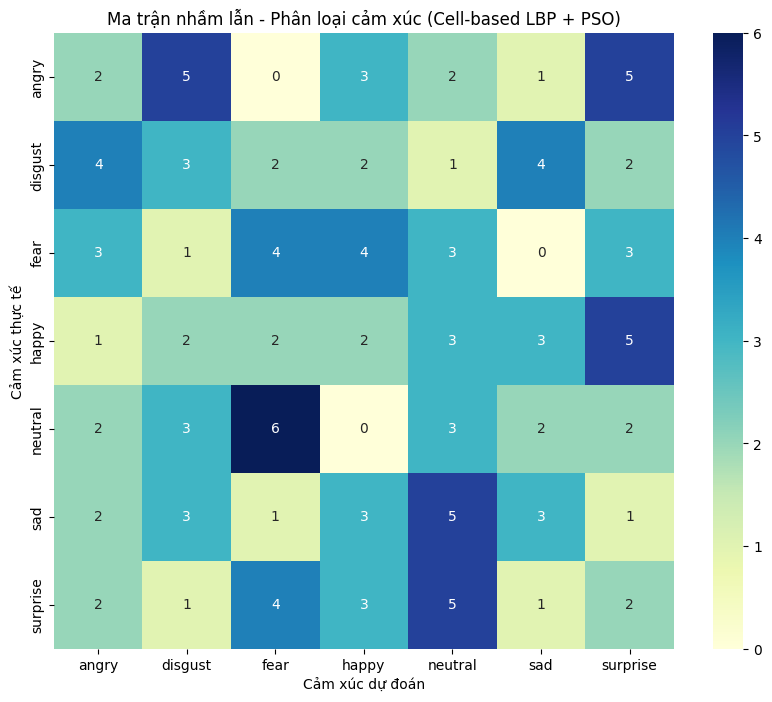

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_grid) # Dùng kết quả từ GridSearch ở trên
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Ma trận nhầm lẫn - Phân loại cảm xúc (Cell-based LBP + PSO)')
plt.ylabel('Cảm xúc thực tế')
plt.xlabel('Cảm xúc dự đoán')
plt.show()

**Biểu đồ các đặc trưng được PSO lựa chọn**

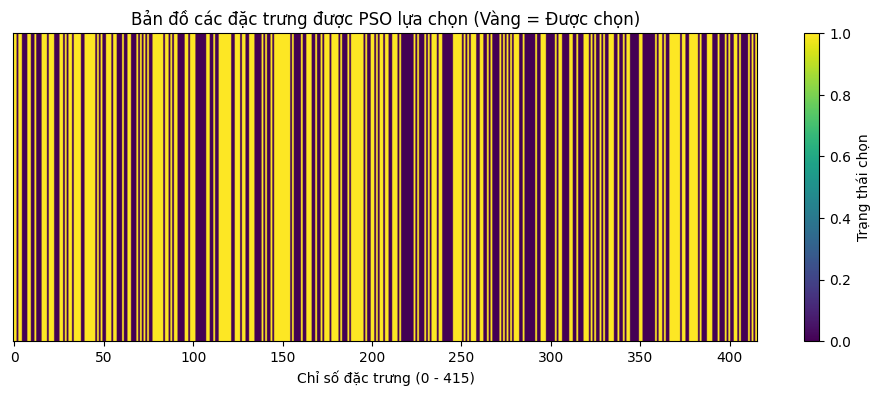

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
# Vẽ mảng nhị phân best_pos (vàng là giữ, tím là bỏ)
plt.imshow(best_pos.reshape(1, -1), aspect='auto', cmap='viridis')
plt.title('Bản đồ các đặc trưng được PSO lựa chọn (Vàng = Được chọn)')
plt.xlabel('Chỉ số đặc trưng (0 - 415)')
plt.yticks([]) # Ẩn trục Y
plt.colorbar(label='Trạng thái chọn')
plt.show()

**Fitness Convergence - Biểu đồ lịch sử hội tụ**

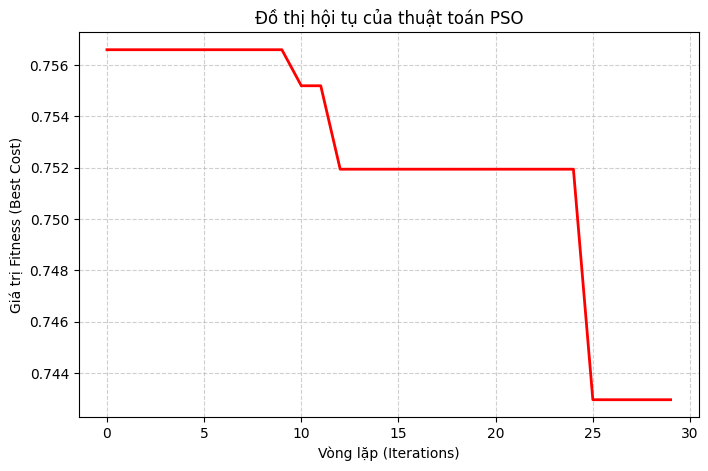

In [ ]:
import matplotlib.pyplot as plt

# Lấy dữ liệu từ optimizer đã chạy
cost_history = optimizer.cost_history

plt.figure(figsize=(8, 5))
plt.plot(cost_history, color='red', linewidth=2)
plt.title('Đồ thị hội tụ của thuật toán PSO')
plt.xlabel('Vòng lặp (Iterations)')
plt.ylabel('Giá trị Fitness (Best Cost)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Feature Reduction - Biểu đồ so sánh số lượng đặc trưng**

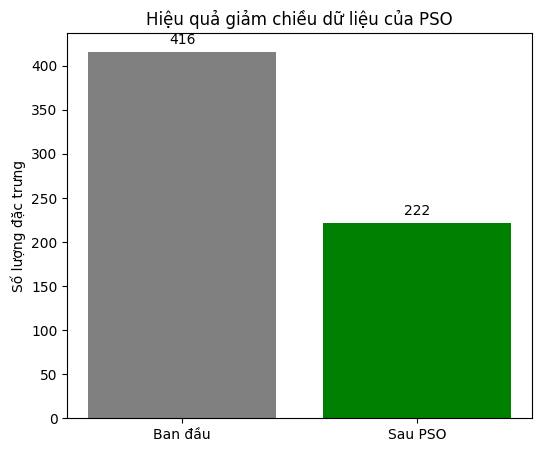

In [ ]:
labels = ['Ban đầu', 'Sau PSO']
values = [416, np.count_nonzero(best_pos)]

plt.figure(figsize=(6, 5))
bars = plt.bar(labels, values, color=['gray', 'green'])
plt.ylabel('Số lượng đặc trưng')
plt.title('Hiệu quả giảm chiều dữ liệu của PSO')

# Ghi số lượng trên đầu cột
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval), ha='center', va='bottom')

plt.show()

**Class Distribution - Biểu đồ hình tròn phân bổ nhãn**

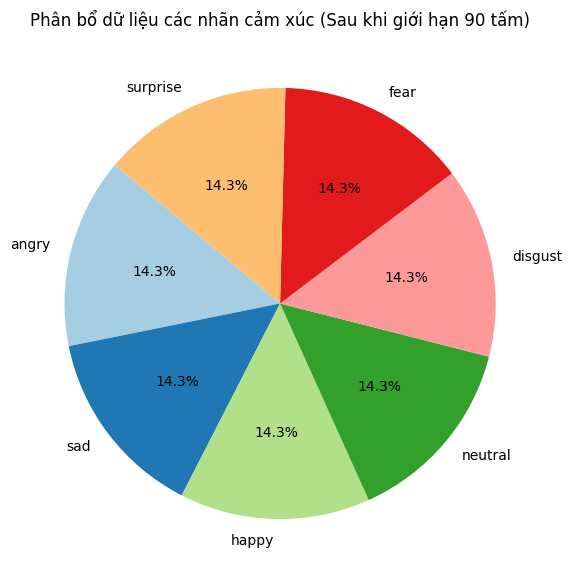

In [ ]:
import pandas as pd

# Đếm số lượng mỗi nhãn trong tập y
df_y = pd.Series(y).value_counts()

plt.figure(figsize=(7, 7))
plt.pie(df_y, labels=df_y.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Phân bổ dữ liệu các nhãn cảm xúc (Sau khi giới hạn 90 tấm)')
plt.show()

**Biểu đồ So sánh Trước và Sau khi tối ưu hóa bằng PSO**

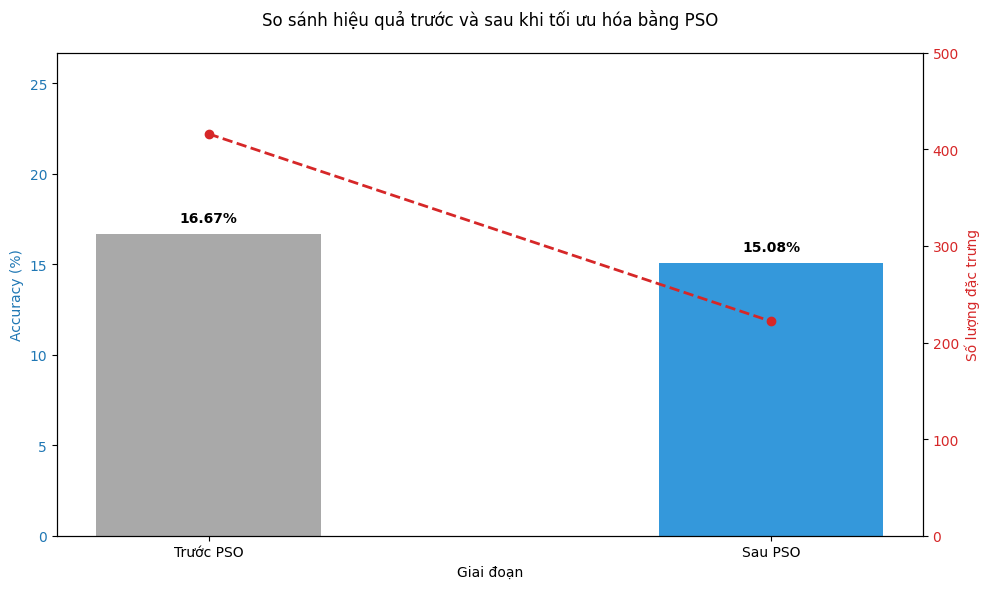

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

acc_before = 16.67
acc_after = 15.08
features_before = 416
features_after = np.count_nonzero(best_pos)

labels = ['Trước PSO', 'Sau PSO']
acc_values = [acc_before, acc_after]
feat_values = [features_before, features_after]

fig, ax1 = plt.subplots(figsize=(10, 6))

# Vẽ cột Accuracy
color = 'tab:blue'
ax1.set_xlabel('Giai đoạn')
ax1.set_ylabel('Accuracy (%)', color=color)
bars = ax1.bar(labels, acc_values, color=['#A9A9A9', '#3498db'], width=0.4, label='Accuracy')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(0, max(acc_values) + 10)

# Ghi số Accuracy trên cột
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5, f'{height:.2f}%', ha='center', va='bottom', fontweight='bold')

# Vẽ đường số lượng đặc trưng (để thấy sự tối ưu)
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Số lượng đặc trưng', color=color)
ax2.plot(labels, feat_values, color=color, marker='o', linestyle='--', linewidth=2, label='Số đặc trưng')
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(0, 500)

plt.title('So sánh hiệu quả trước và sau khi tối ưu hóa bằng PSO', pad=20)
fig.tight_layout()
plt.show()